Wykresy z treningu HiFi-GAN

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_json(filename):
    """
    Convert the standard output saved to filename into a pandas dataframe for analysis.
    """

    with open(filename, "r") as f:
        data = f.read()

    data = [json.loads(l.strip("DLLL")) for l in data.splitlines()]
    return pd.DataFrame(data)

In [ ]:
logs_file_path = "./checkpoints/fine-tuning_50e/results/nvlog.json"

assert os.path.isfile(logs_file_path)
df = read_json(logs_file_path)

In [23]:
df_train_epochs = df[df["data"].apply(lambda x: isinstance(x, dict) and "train_avg_took" in x.keys())]
df_train_epochs["step"] = df_train_epochs["step"].apply(lambda x: x[0] if x else None)
data_expanded = df_train_epochs["data"].apply(pd.Series)
df_train_epochs = pd.concat([df_train_epochs, data_expanded], axis=1)
df_train_epochs = df_train_epochs.drop(["data"], axis=1)


df_val_epochs = df[df["data"].apply(lambda x: isinstance(x, dict) and "val_took" in x.keys())]
df_val_epochs["step"] = df_val_epochs["step"].apply(lambda x: x[0] if x else None)
data_expanded = df_val_epochs["data"].apply(pd.Series)
df_val_epochs = pd.concat([df_val_epochs, data_expanded], axis=1)
df_val_epochs = df_val_epochs.drop(["data"], axis=1)
df_val_epochs = df_val_epochs.dropna(subset=["step"])


print(f"train epochs: {len(df_train_epochs)}, val epochs: {len(df_val_epochs)}")

train epochs: 50, val epochs: 50


In [ ]:
# dla fine-tuningu
if df_train_epochs["step"].iloc[0] == 6501 and df_val_epochs["step"].iloc[0] == 6501:
    df_train_epochs["step"] -= 6500
    df_val_epochs["step"] -= 6500

In [25]:
df_train_epochs.head()

,timestamp,elapsedtime,datetime,type,metric,metadata,step,train_avg_loss_discrim,train_avg_loss_gen,train_avg_loss_mel,train_avg_lrate_gen,train_avg_lrate_discrim,train_avg_frames/s,train_avg_took
85,1777022932.251127,175.911953,2026-04-24 09:28:52.251127,LOG,NaN,NaN,1,4.207471,30.365014,26.816193,0.00003,0.00003,700.568703,171.746182
92,1777023102.530001,346.190827,2026-04-24 09:31:42.530001,LOG,NaN,NaN,2,3.933487,22.993813,19.754267,0.00003,0.00003,869.942003,138.308071
99,1777023271.361195,515.022021,2026-04-24 09:34:31.361195,LOG,NaN,NaN,3,3.924157,21.504895,18.158250,0.00003,0.00003,865.762331,138.975785
105,1777023440.568241,684.229067,2026-04-24 09:37:20.568241,LOG,NaN,NaN,4,3.878476,20.712310,17.273170,0.00003,0.00003,864.732883,139.141233
112,1777023608.991101,852.651927,2026-04-24 09:40:08.991101,LOG,NaN,NaN,5,3.865387,20.117912,16.598591,0.00003,0.00003,868.742155,138.499092


In [26]:
df_val_epochs.head()

,timestamp,elapsedtime,datetime,type,metric,metadata,step,val_loss_discrim,val_loss_gen,val_loss_mel,val_frames/s,val_took
86,1777022964.220036,207.880862,2026-04-24 09:29:24.220036,LOG,NaN,NaN,1.0,4.010731,22.539896,19.555380,2289.878327,31.966764
93,1777023132.384198,376.045024,2026-04-24 09:32:12.384198,LOG,NaN,NaN,2.0,3.937949,20.590454,17.336511,2452.047132,29.852607
100,1777023301.425747,545.086573,2026-04-24 09:35:01.425747,LOG,NaN,NaN,3.0,3.942800,19.400698,16.287469,2434.908253,30.062734
106,1777023470.490982,714.151808,2026-04-24 09:37:50.490982,LOG,NaN,NaN,4.0,3.919173,19.037385,15.834313,2446.440387,29.921023
113,1777023638.818244,882.47907,2026-04-24 09:40:38.818244,LOG,NaN,NaN,5.0,3.873119,18.960498,15.374077,2454.263186,29.825652


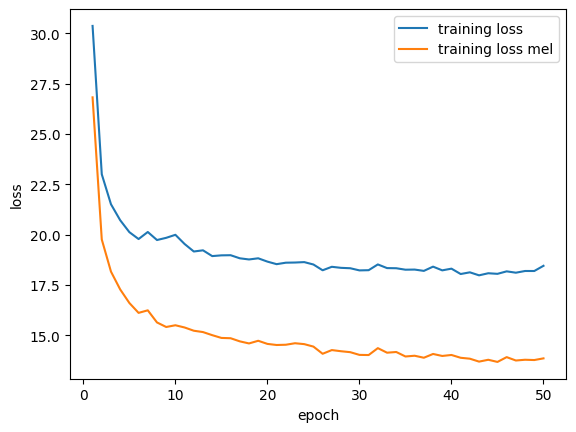

In [27]:
plt.plot(df_train_epochs["step"], df_train_epochs["train_avg_loss_gen"], label="training loss")
plt.plot(df_train_epochs["step"], df_train_epochs["train_avg_loss_mel"], label="training loss mel")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

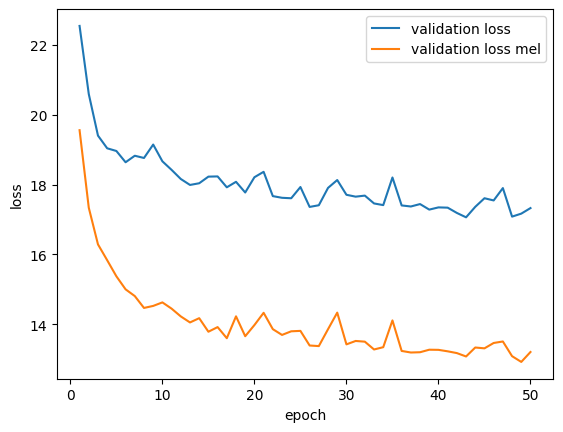

In [28]:
# 'val_loss_discrim', 'val_loss_gen', 'val_loss_mel', 'val_frames/s', 'val_took'
plt.plot(df_val_epochs["step"], df_val_epochs["val_loss_gen"], label="validation loss")
plt.plot(df_val_epochs["step"], df_val_epochs["val_loss_mel"], label="validation loss mel")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

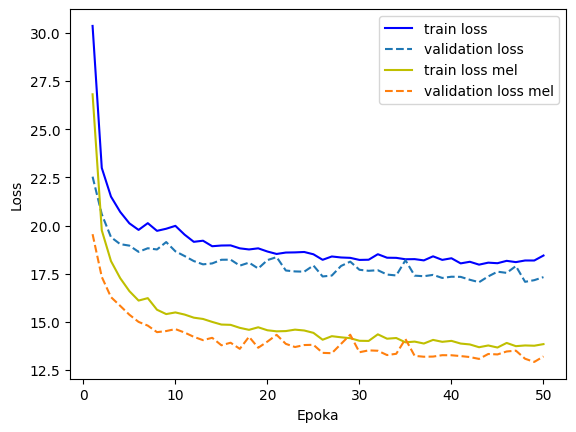

In [29]:
plt.plot(df_train_epochs["step"], df_train_epochs["train_avg_loss_gen"], "b", label="train loss")
plt.plot(df_val_epochs["step"], df_val_epochs["val_loss_gen"], "--", label="validation loss")
plt.plot(df_train_epochs["step"], df_train_epochs["train_avg_loss_mel"], "y", label="train loss mel")
plt.plot(df_val_epochs["step"], df_val_epochs["val_loss_mel"], "--", label="validation loss mel")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.legend()
plt.show()

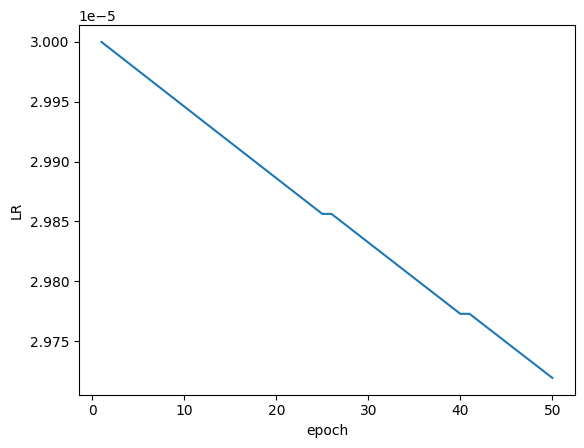

In [30]:
plt.plot(df_train_epochs["step"], df_train_epochs["train_avg_lrate_gen"])
plt.ticklabel_format(axis="y", scilimits=[-4, 6])
plt.xlabel("epoch")
plt.ylabel("LR")
plt.show()